## Литература
Application of machine learning algorithms for population forecasting, 2021

The target variable is determined as the total population value of 2017. Валидацию делали на Турции.

Здесь мы будем предсказывать на 10 лет вперёд, целевая переменная будет численность населения 2013-2022 включительно. Здесь мы делаем валидацию на России без учёта Крыма.

## Baseline
### Naïve (Last Observation)

Официальный базовый метод временных рядов (Hyndman & Athanasopoulos, *Forecasting*).

**Формула:**

\[
\hat{y}_{t+h} = y_t
\]

Прогноз равен последнему известному значению.

**Почему это baseline:**  
Любая модель должна быть лучше сценария «ничего не меняется». В демографии тренды часто инерционные, поэтому такой тест особенно важен.

Синонимы: **Naïve Forecast**, **Last Value Forecast**.

---

### 2) Linear Trend (OLS Extrapolation)

Классический демографический базовый метод для сравнения со сложными моделями.

**Модель:**

\[
y_t = a + b t
\]

Подгоняется по обучающему отрезку, затем линейно экстраполируется на годы \(t+1,\ldots,t+H\).

**Почему используется:**  
Демографические организации (UN, Eurostat) приводят линейную аппроксимацию как технический среднесрочный ориентир и минимальный структурный baseline.

Название: **Linear Trend Extrapolation**.


### Метрики для сравнения моделей
Взяты из статьи 
#### 1) MAPE (Mean Absolute Percentage Error)

\[
\text{MAPE} = \frac{1}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right|
\]


#### 2) RMSE (Root Mean Squared Error)
\[
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
\]


### 3) SDEV ошибок (стандартное отклонение абсолютных ошибок)
Нужно для анализа стабильности модели между странами и годами.  
MAPE может быть одинаковым у двух моделей, но одна стабильна, а другая «стреляющая» — SDEV это показывает.
\[
\text{SDEV} = \sqrt{\frac{1}{n}\sum_{i=1}^n (e_i - \bar{e})^2}
\]
где \(e_i = |y_i - \hat{y}_i|\).


### 3 Rolling Windows

Для оценки стабильности моделей по времени используются три окна:

1. **Окно A:** train до 1999, тест 2000–2009  
2. **Окно B:** train до 2004, тест 2005–2014  
3. **Окно C:** train до 2012, тест 2013–2022  

Каждое окно покрывает 10 лет прогнозирования. Три окна позволяют проверить, насколько модели устойчивы к различным историческим периодам, выявить зависимость качества прогнозов от трендов и колебаний населения. Такой подход имитирует скользящий forecast, что часто применяют в демографии для оценки краткосрочной и среднесрочной точности моделей.

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("output/wide_unfiltered.csv")
df_filtered =  pd.read_csv("output/wide_filtered.csv")
#df = pd.read_csv("output/merged_worldbank_long_no_nan.csv")
def naive_forecast(train_series, horizon):
    last_value = train_series.iloc[-1]
    return np.array([last_value] * horizon)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

def rmse_perc(y_true, y_pred):
    rmse_val = np.sqrt(np.mean((y_true - y_pred)**2))
    return rmse_val / np.mean(y_true)

def sdev_perc(y_true, y_pred):
    e = np.abs(y_true - y_pred)
    return e.std() / np.mean(y_true)
# Определяем 3 окна
windows = [
    ('A', 1999, 10),  # train до 1999, тест 2000–2009
    ('B', 2004, 10),  # train до 2004, тест 2005–2014
    ('C', 2012, 10)   # train до 2012, тест 2013–2022
]
models_results = {}
def print_model_summary(model_name):
    for train_type in models_results[model_name]:
        print(f"\n=== Model: {model_name} | Train type: {train_type} ===")
        for window_name in models_results[model_name][train_type]:
            res = models_results[model_name][train_type][window_name]
            print(f"Window {window_name}: MAPE={res['MAPE']:.3f}, RMSE={res['RMSE']:.3f}, SDEV={res['SDEV']:.3f}")
pop_cols = []
for c in df.columns:
    if c.startswith("Population_"):
        tail = c.split("_")[1]
        if  c[len("Population_"):].isdigit() and len(tail) == 4:
            pop_cols.append(c)
print(pop_cols)

['Population_1960', 'Population_1961', 'Population_1962', 'Population_1963', 'Population_1964', 'Population_1965', 'Population_1966', 'Population_1967', 'Population_1968', 'Population_1969', 'Population_1970', 'Population_1971', 'Population_1972', 'Population_1973', 'Population_1974', 'Population_1975', 'Population_1976', 'Population_1977', 'Population_1978', 'Population_1979', 'Population_1980', 'Population_1981', 'Population_1982', 'Population_1983', 'Population_1984', 'Population_1985', 'Population_1986', 'Population_1987', 'Population_1988', 'Population_1989', 'Population_1990', 'Population_1991', 'Population_1992', 'Population_1993', 'Population_1994', 'Population_1995', 'Population_1996', 'Population_1997', 'Population_1998', 'Population_1999', 'Population_2000', 'Population_2001', 'Population_2002', 'Population_2003', 'Population_2004', 'Population_2005', 'Population_2006', 'Population_2007', 'Population_2008', 'Population_2009', 'Population_2010', 'Population_2011', 'Population

In [19]:
def run_naive_wide(df_wide, windows):
    if 'naive' not in models_results:
        models_results['naive'] = {}

    years = sorted([int(c.split("_")[1]) for c in pop_cols])
    col_by_year = {y: f"Population_{y}" for y in years}

    for window_name, train_end_year, horizon in windows:
        models_results['naive'][window_name] = {}
        all_mape, all_rmse, all_sdev = [], [], []

        for i, row in df_wide.iterrows():
            country = row["country_code"]

            pop_series = np.array([row[col_by_year[y]] for y in years], dtype="float64")

            # индексы train/test по годам
            train_mask = np.array([y <= train_end_year for y in years])
            test_mask  = np.array([(train_end_year < y <= train_end_year + horizon) for y in years])

            if train_mask.sum() == 0 or test_mask.sum() == 0:
                continue

            y_train = pop_series[train_mask]
            y_test  = pop_series[test_mask]

            valid = ~np.isnan(y_train)

            last_value = y_train[valid][-1]         
            y_pred = np.full(len(y_test), last_value) # naive = повторяем
            mask_val = ~np.isnan(y_test)

            yt = y_test[mask_val]
            yp = y_pred[:len(yt)]

            r = {
                'MAPE': mape(yt, yp),
                'RMSE': rmse_perc(yt, yp),
                'SDEV': sdev_perc(yt, yp)
            }
            all_mape.append(r['MAPE'])
            all_rmse.append(r['RMSE'])
            all_sdev.append(r['SDEV'])

        print(f"Naive baseline — {window_name}")
        print(f"MAPE: {np.mean(all_mape):.3f}, RMSE: {np.mean(all_rmse):.3f}, SDEV: {np.mean(all_sdev):.3f}\n")


In [20]:
run_naive_wide(df, windows)

Naive baseline — A
MAPE: 0.084, RMSE: 0.100, SDEV: 0.049

Naive baseline — B
MAPE: 0.085, RMSE: 0.100, SDEV: 0.048

Naive baseline — C
MAPE: 0.078, RMSE: 0.090, SDEV: 0.041



In [15]:
if 'PSE' in df['country_code'].values:
    print("В df есть PSE")
else:
    print("В df PSE нет")

# Проверка в df_filtered
if 'PSE' in df_filtered['country_code'].values:
    print("В df_filtered есть PSE")
else:
    print("В df_filtered PSE нет")

В df PSE нет
В df_filtered PSE нет


Нельзя по странам даже с box-cox преобразованием: MAPE будет ~1

In [33]:
from sklearn.linear_model import LinearRegression
import numpy as np
from scipy.stats import boxcox
from scipy.special import inv_boxcox

def run_linear_trend_all_country(df_wide, model_name):
    if model_name not in models_results:
        models_results[model_name] = {}

    years = np.array([int(c.split("_")[1]) for c in pop_cols])

    for window_name, train_end_year, horizon in windows:
        train_mask = years <= train_end_year
        test_mask  = (years > train_end_year) & (years <= train_end_year + horizon)
        if train_mask.sum() == 0 or test_mask.sum() == 0:
            models_results[model_name][window_name] = {'MAPE': np.nan,'RMSE': np.nan,'SDEV': np.nan}
            continue

        X_train_base = years[train_mask].reshape(-1,1)
        X_test = years[test_mask].reshape(-1,1)

        y_train_all = []
        valid_rows = []

        for i, row in df_wide.iterrows():
            vals = row[pop_cols].values.astype(float)
            yt = vals[train_mask]
            if np.isnan(yt).any():
                continue
            y_train_all.append(yt)
            valid_rows.append(i)

        if not y_train_all:
            models_results[model_name][window_name] = {'MAPE': np.nan,'RMSE': np.nan,'SDEV': np.nan}
            continue

        y_train_all = np.concatenate(y_train_all)
        X_train_all = np.tile(X_train_base, (len(valid_rows),1))
        y_train_all_bc, fitted_lambda = boxcox(y_train_all + 1e-6)

        model = LinearRegression()
        model.fit(X_train_all, y_train_all_bc)
        y_pred_bc = model.predict(X_test)
        y_pred = inv_boxcox(y_pred_bc, fitted_lambda)

        mape_list, rmse_list, sdev_list = [], [], []

        for i in valid_rows:
            vals = df_wide.loc[i, pop_cols].values.astype(float)
            y_test_country = vals[test_mask]
            if np.isnan(y_test_country).any():
                continue
            y_pred = model.predict(X_test)
            mape_list.append(mape(y_test_country, y_pred))
            rmse_list.append(rmse_perc(y_test_country, y_pred))
            sdev_list.append(sdev_perc(y_test_country, y_pred))


        models_results[model_name][window_name] = {
            'MAPE': float(np.mean(mape_list)),
            'RMSE': float(np.mean(rmse_list)),
            'SDEV': float(np.mean(sdev_list))
        }


In [34]:
run_linear_trend_all_country(df, 'linear_regression_population')
print(models_results['linear_regression_population'])

{'A': {'MAPE': 0.999998812687052, 'RMSE': 1.0020021955130425, 'SDEV': 0.04924938318210334}, 'B': {'MAPE': 0.9999989233973994, 'RMSE': 1.0018070506613224, 'SDEV': 0.048015120336878145}, 'C': {'MAPE': 0.9999990435613723, 'RMSE': 1.0012155325056527, 'SDEV': 0.04142009396790424}}


In [30]:
df_long_filtered = pd.read_csv("output/basic_with_cohort_filtered.csv")
df_long_unfiltered = pd.read_csv("output/basic_with_cohort_unfiltered.csv")
print(df_long_filtered.columns)

Index(['Unnamed: 0', 'country_code', 'year', 'Pop_density',
       'Urban_pop_largest_city', 'Urban_pop_largest_city_percent',
       'Urban_pop_medium_cities_percent', 'Crude_death_rate', 'Net_migration',
       'Adolescent_total_fertility_rate', 'Crude_birth_rate',
       'Crude_death_rate_worldbank', 'Life_expectancy_female',
       'Life_expectancy_total', 'Life_expectancy_male', 'Total_fertility_rate',
       'Population_0_14_percent', 'Population_65plus_percent',
       'Population_total', 'Urban_population_growth', 'Urban_population_total',
       'Urban_population_percent', 'mort_0_4', 'mort_100_100', 'mort_10_14',
       'mort_15_19', 'mort_20_24', 'mort_25_29', 'mort_30_34', 'mort_35_39',
       'mort_40_44', 'mort_45_49', 'mort_50_54', 'mort_55_59', 'mort_5_9',
       'mort_60_64', 'mort_65_69', 'mort_70_74', 'mort_75_79', 'mort_80_84',
       'mort_85_89', 'mort_90_94', 'mort_95_99', 'asfr_10_14', 'asfr_15_19',
       'asfr_20_24', 'asfr_25_29', 'asfr_30_34', 'asfr_35_39', 

In [44]:
from sklearn.linear_model import LinearRegression
import numpy as np
def run_linear_country_windows(df_wide, model_name='linear_country_population'):
    models_results[model_name] = {}

    years = np.array([int(c.split("_")[1]) for c in pop_cols])

    for window_name, train_end_year, horizon in windows:
        train_mask = years <= train_end_year
        test_mask  = (years > train_end_year) & (years <= train_end_year + horizon)

        if train_mask.sum() == 0 or test_mask.sum() == 0:
            models_results[model_name][window_name] = {'MAPE': np.nan,'RMSE': np.nan,'SDEV': np.nan}
            continue

        mape_list, rmse_list, sdev_list = [], [], []

        for country in df_wide['country_code'].unique():
            row = df_wide[df_wide['country_code'] == country].iloc[0]
            pop_vals = row[pop_cols].values.astype(float)

            y_train = pop_vals[train_mask]
            y_test  = pop_vals[test_mask]

            # игнорируем NaN
            if np.isnan(y_train).any() or np.isnan(y_test).any():
                continue

            X_train = years[train_mask].reshape(-1,1)
            X_test  = years[test_mask].reshape(-1,1)

            model = LinearRegression()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            mape_list.append(mape(y_test, y_pred))
            rmse_list.append(rmse_perc(y_test, y_pred))
            sdev_list.append(sdev_perc(y_test, y_pred))

        # среднее по странам
        models_results[model_name][window_name] = {
            'MAPE': round(float(np.mean(mape_list)), 4),
            'RMSE': round(float(np.mean(rmse_list)), 4),
            'SDEV': round(float(np.mean(sdev_list)), 4)
        }

# Запуск
run_linear_country_windows(df)
print(models_results['linear_country_population'])


{'A': {'MAPE': 0.0778, 'RMSE': 0.0842, 'SDEV': 0.0262}, 'B': {'MAPE': 0.0872, 'RMSE': 0.0931, 'SDEV': 0.0261}, 'C': {'MAPE': 0.0949, 'RMSE': 0.0987, 'SDEV': 0.0225}}


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

def run_linear_country_all(df_wide, model_name='linear_country_all'):
    models_results[model_name] = {}

    years = np.array([int(c.split("_")[1]) for c in pop_cols])

    for window_name, train_end_year, horizon in windows:
        train_mask = years <= train_end_year
        test_mask  = (years > train_end_year) & (years <= train_end_year + horizon)

        if train_mask.sum() == 0 or test_mask.sum() == 0:
            models_results[model_name][window_name] = {'MAPE': np.nan,'RMSE': np.nan,'SDEV': np.nan}
            continue

        mape_list, rmse_list, sdev_list = [], [], []

        for country in df_wide['country_code'].unique():
            row = df_wide[df_wide['country_code'] == country].iloc[0]

            # Train — все годы популяции
            y_train = row[pop_cols].values.astype(float)[train_mask]

            # Test — все колонки, но только годы из окна
            y_test = row.values[test_mask + (row.index.get_loc('country_code'),)]  # исключаем страну

            X_train = years[train_mask].reshape(-1,1)
            X_test  = years[test_mask].reshape(-1,1)

            model = LinearRegression()
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            mape_list.append(mape(y_test, y_pred))
            rmse_list.append(rmse_perc(y_test, y_pred))
            sdev_list.append(sdev_perc(y_test, y_pred))

        models_results[model_name][window_name] = {
            'MAPE': round(float(np.mean(mape_list)), 4),
            'RMSE': round(float(np.mean(rmse_list)), 4),
            'SDEV': round(float(np.mean(sdev_list)), 4)
        }

run_linear_country_all(df)
print(models_results['linear_country_all'])


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Попробуем взять чисто Population

In [30]:
from sklearn.linear_model import LinearRegression

models_results['linear_trend_filtered'] = {}

for window_name, train_end_year, horizon in windows:
    models_results['linear_trend_filtered'][window_name] = {}
    
    for country in df_filtered['country_code'].unique():
        df_c = df_filtered[df_filtered['country_code'] == country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]

        X_train = train['Population_total'].shift(1).values.reshape(-1, 1)
        y_train = train['Population_total'].values

        X_test = test['Population_total'].shift(1).values.reshape(-1, 1)
        y_test = test['Population_total'].values

        X_train = X_train[1:]
        y_train = y_train[1:]

        X_test = X_test[1:]
        y_test = y_test[1:]

        if len(X_train) == 0 or len(X_test) == 0:
            continue
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        models_results['linear_trend_filtered'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
        }

print_model_summary('linear_trend_filtered')


model Linear_Trend_Filtered - window A:
  MAPE: 0.007, RMSE: 0.008, SDEV: 0.003

model Linear_Trend_Filtered - window B:
  MAPE: 0.006, RMSE: 0.007, SDEV: 0.003

model Linear_Trend_Filtered - window C:
  MAPE: 0.006, RMSE: 0.007, SDEV: 0.003



In [27]:
from sklearn.linear_model import LinearRegression

models_results['linear_trend_filtered'] = {}

for window_name, train_end_year, horizon in windows:
    models_results['linear_trend_filtered'][window_name] = {}
    
    for country in df_filtered['country_code'].unique():
        df_c = df_filtered[df_filtered['country_code'] == country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]
        
        X_train = train['year'].values.reshape(-1, 1)
        y_train = train['Population_total'].values
        X_test = test['year'].values.reshape(-1, 1)
        y_test = test['Population_total'].values
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        models_results['linear_trend_filtered'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
        }

print_model_summary('linear_trend_filtered')


model Linear_Trend_Filtered - window A:
  MAPE: 0.078, RMSE: 0.084, SDEV: 0.026

model Linear_Trend_Filtered - window B:
  MAPE: 0.087, RMSE: 0.093, SDEV: 0.026

model Linear_Trend_Filtered - window C:
  MAPE: 0.095, RMSE: 0.099, SDEV: 0.022



In [29]:
from sklearn.linear_model import LinearRegression
import pandas as pd

models_results['linear_trend_filtered'] = {}

df_use = df_filtered.sort_values(['country_code', 'year'])
df_use = df_use.dropna(subset=['Population_total'])

countries = df_use['country_code'].unique()
df_dummies = pd.get_dummies(df_use['country_code'], prefix='ctry')
dummy_cols = df_dummies.columns
df_use = pd.concat([df_use.reset_index(drop=True), df_dummies.reset_index(drop=True)], axis=1)

for window_name, train_end_year, horizon in windows:
    models_results['linear_trend_filtered'][window_name] = {}
    
    df_train = df_use[df_use['year'] <= train_end_year]
    df_test  = df_use[(df_use['year'] > train_end_year) & (df_use['year'] <= train_end_year + horizon)]

    X_train = pd.concat([df_train[['year']], df_train[dummy_cols]], axis=1).values
    y_train = df_train['Population_total'].values

    model = LinearRegression()
    model.fit(X_train, y_train)

    for country in countries:
        df_c_test = df_test[df_test['country_code'] == country]
        if df_c_test.empty:
            continue

        X_test = pd.concat([df_c_test[['year']], df_c_test[dummy_cols]], axis=1).values
        y_test = df_c_test['Population_total'].values
        y_pred = model.predict(X_test)

        models_results['linear_trend_filtered'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
        }

print_model_summary('linear_trend_filtered')


model Linear_Trend_Filtered - window A:
  MAPE: 16.197, RMSE: 16.270, SDEV: 1.851

model Linear_Trend_Filtered - window B:
  MAPE: 16.547, RMSE: 16.623, SDEV: 1.721

model Linear_Trend_Filtered - window C:
  MAPE: 17.319, RMSE: 17.399, SDEV: 1.578



In [28]:
from xgboost import XGBRegressor

basic_features = ['age_0_14_share', 'age_65_plus_share', 'crude_birth_rate', 'crude_death_rate',
            'fertility_rate', 'life_expectancy', 'net_migration', 'urban_share', 'gdppc']
features = train.select_dtypes(include=['number']).columns.tolist()
features = [c for c in features if c != 'population']

models_results['xgboost'] = {}
models_results['xgboost-simple_data'] = {}

In [29]:
for window_name, train_end_year, horizon in windows:
    models_results['xgboost-simple_data'][window_name] = {}
    
    for country in df['country_code'].unique():
        df_c = df[df['country_code'] == country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]
        
        X_train = train[basic_features].values
        y_train = train['population'].values
        X_test = test[basic_features].values
        y_test = test['population'].values
        
        model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        models_results['xgboost-simple_data'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
            'pred': y_pred,
            'true': y_test
        }

In [30]:
for window_name, train_end_year, horizon in windows:
    models_results['xgboost'][window_name] = {}
    
    for country in df['country_code'].unique():
        df_c = df[df['country_code'] == country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]
        
        X_train = train[features].values
        y_train = train['population'].values
        X_test = test[features].values
        y_test = test['population'].values
        
        model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        models_results['xgboost'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
            'pred': y_pred,
            'true': y_test
        }

print_model_summary('xgboost')
print_model_summary('xgboost-simple_data')

model Xgboost - window A:
  MAPE: 0.087, RMSE: 0.104, SDEV: 0.051

model Xgboost - window B:
  MAPE: 0.089, RMSE: 0.104, SDEV: 0.050

model Xgboost - window C:
  MAPE: 0.082, RMSE: 0.095, SDEV: 0.043

model Xgboost-Simple_Data - window A:
  MAPE: 0.109, RMSE: 0.127, SDEV: 0.057

model Xgboost-Simple_Data - window B:
  MAPE: 0.103, RMSE: 0.121, SDEV: 0.057

model Xgboost-Simple_Data - window C:
  MAPE: 0.105, RMSE: 0.120, SDEV: 0.053



In [107]:
from prophet import Prophet

models_results['prophet'] = {}

for window_name, train_end_year, horizon in windows:
    models_results['prophet'][window_name] = {}
    
    for country in df['country_code'].unique():
        df_c = df
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]
        
        # Prophet требует колонки 'ds' (дата) и 'y' (значение)
        train_prophet = train[['year', 'population']].rename(columns={'year': 'ds', 'population': 'y'})
        train_prophet['ds'] = pd.to_datetime(train_prophet['ds'], format='%Y')
        
        model = Prophet(yearly_seasonality=False, daily_seasonality=False, weekly_seasonality=False)
        model.fit(train_prophet)
        
        future = pd.DataFrame({'ds': pd.date_range(start=str(train_end_year+1), periods=horizon, freq='YE')})
        forecast = model.predict(future)
        y_pred = forecast['yhat'].values
        y_test = test['population'].values
        
        models_results['prophet'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
            'pred': y_pred,
            'true': y_test
        }

print_model_summary('prophet')


22:47:39 - cmdstanpy - INFO - Chain [1] start processing
22:47:39 - cmdstanpy - INFO - Chain [1] done processing


ValueError: operands could not be broadcast together with shapes (1440,) (10,) 

Cohort_component без cohort не работает

In [32]:
models_results['cohort_component_basic'] = {}

for window_name, train_end_year, horizon in windows:
    models_results['cohort_component_basic'][window_name] = {}
    
    for country in df['country_code'].unique():
        df_c = df[df['country_code'] == country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]
        
        # численность когорт на последний год train
        pop_total = train['population'].iloc[-1]
        pop_0_14 = pop_total * train['age_0_14_share'].iloc[-1]
        pop_15_64 = pop_total - pop_0_14 - pop_total * train['age_65_plus_share'].iloc[-1]
        pop_65_plus = pop_total * train['age_65_plus_share'].iloc[-1]
        
        y_pred = []
        for i in range(horizon):
            # простая имитация CCM: выживаемость + рождаемость + миграция
            births = pop_15_64 * train['fertility_rate'].iloc[-1] / 1000  # упрощение
            deaths = pop_total * train['crude_death_rate'].iloc[-1] / 1000
            net_mig = train['net_migration'].iloc[-1]
            
            pop_total = pop_total + births - deaths + net_mig
            y_pred.append(pop_total)
        
        y_test = test['population'].values
        
        models_results['cohort_component_basic'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
            'pred': y_pred,
            'true': y_test
        }

print_model_summary('cohort_component_basic')


model Cohort_Component_Basic - window A:
  MAPE: 0.801, RMSE: 0.927, SDEV: 0.425

model Cohort_Component_Basic - window B:
  MAPE: 0.732, RMSE: 0.847, SDEV: 0.388

model Cohort_Component_Basic - window C:
  MAPE: 0.663, RMSE: 0.763, SDEV: 0.348



### Когортная модель
Когортная модель демографии прогнозирует численность населения, разделённого по возрастным группам, учитывая выживаемость, рождаемость и миграцию. Каждая когорте переносится на следующий возраст, новорождённые рассчитываются через возрастные коэффициенты рождаемости женщин, смертность вычитается по возрастам, миграция распределяется пропорционально. Модель позволяет прогнозировать динамику населения с высокой детализацией.

Мы считаем для когорт 5-летних

In [37]:
models_results['cohort_component'] = {}

cohort_cols = [
    'Pop0_4','Pop5_9','Pop10_14','Pop15_19','Pop20_24','Pop25_29','Pop30_34',
    'Pop35_39','Pop40_44','Pop45_49','Pop50_54','Pop55_59','Pop60_64',
    'Pop65_69','Pop70_74','Pop75_79','Pop80_84','Pop85_89','Pop90_94',
    'Pop95_99','Pop100plus'
]

mort_cols = [
    'mort_0_4','mort_5_9','mort_10_14','mort_15_19','mort_20_24','mort_25_29',
    'mort_30_34','mort_35_39','mort_40_44','mort_45_49','mort_50_54','mort_55_59',
    'mort_60_64','mort_65_69','mort_70_74','mort_75_79','mort_80_84','mort_85_89',
    'mort_90_94','mort_95_99','mort_100_100'
]

asfr_cols = [
    'asfr_10_14','asfr_15_19','asfr_20_24','asfr_25_29','asfr_30_34',
    'asfr_35_39','asfr_40_44','asfr_45_49','asfr_50_54'
]

fertile_cohorts = ['Pop10_14','Pop15_19','Pop20_24','Pop25_29','Pop30_34',
                   'Pop35_39','Pop40_44','Pop45_49','Pop50_54']


In [59]:
def get_births(population, cohort_vals, asfr_rates):
    absolute_cohorts = cohort_vals * population
    female_cohorts = absolute_cohorts / 2
    births = (female_cohorts * (asfr_rates / 1000)).sum()
    return births
def get_population_peoples(population, cohort_vals):
    return cohort_vals * population
def get_deaths_peoples(deaths_vals):
    return deaths_vals * 1000

def shift_cohorts_one_year(pop_cohorts):
    """
    Считаем что в когорте люди распределены равномерно, поэтому при сдвиге на год 1/5 перемещается
    """
    n = len(pop_cohorts)
    new_cohorts = np.zeros_like(pop_cohorts)
    for i in range(1, n-1):
        new_cohorts[i] = pop_cohorts[i-1] * 0.2 + pop_cohorts[i] * 0.8
    new_cohorts[0] = 0.8*pop_cohorts[0]
    new_cohorts[-1] = pop_cohorts[-2] * 0.2 + pop_cohorts[-1]

    return new_cohorts

In [60]:
import numpy as np
import pandas as pd

df = pd.read_csv("output/final_with_cohort.csv")

afg_1960 = df[(df['country_code'] == 'AFG') & (df['year'] == 1960)]
population = afg_1960['population'].iloc[0]

pop_cohorts = afg_1960[cohort_cols].iloc[0].values.astype(float)
deaths_vals = afg_1960[mort_cols].iloc[0].values.astype(float)
asfr_rates = afg_1960[asfr_cols].iloc[0].values
fertile_vals = afg_1960[fertile_cohorts].iloc[0].values.astype(float)

# Пересчёт в абсолютные значения
pop_peoples = get_population_peoples(population, pop_cohorts)
deaths_peoples = get_deaths_peoples(deaths_vals)
births = get_births(population, fertile_vals, asfr_rates)
print("births", births.astype(int))
print("deaths_peoples", deaths_peoples.astype(int))
print("pop_peoples", pop_peoples)


births 485285
deaths_peoples [158051  10106   6782   7857   9181   8859   8774   8456   8196   7768
   8183   8452   9134   8908   7885   5698   2852    869    136     11
      0]
pop_peoples [1543000. 1180000. 1067000.  924000.  803000.  693000.  599000.  504000.
  422000.  350000.  286000.  233000.  176000.  125000.   76000.   37000.
   13000.    3000.       0.       0.       0.]


In [71]:
pop_after_deaths = pop_peoples - deaths_peoples
pop_next_year = shift_cohorts_one_year(pop_after_deaths)
pop_next_year[0]+= births
# Миграция, пропорционально существующим когортам
net_mig = afg_1960['net_migration'].iloc[0]
total_pop_before_mig = pop_next_year.sum()
pop_next_year += pop_next_year / total_pop_before_mig * net_mig
total_population_next_year = pop_next_year.sum()
print("Быдл", pop_peoples.sum())
print("Общее население через год:", int(total_population_next_year))
afg_1961 = df[(df['country_code'] == 'AFG') & (df['year'] == 1961)]
population_1961 = afg_1961['population'].iloc[0]

print("Population Afghanistan 1961:", population_1961)

Быдл 9033999.999999993
Общее население через год: 9234986
Population Afghanistan 1961: 9214083


In [66]:
fertile_idx = [cohort_cols.index(c) for c in fertile_cohorts]  # should be 2..10

for window_name, train_end_year, horizon in windows:
    models_results['cohort_component'][window_name] = {}
    for country in sorted(df['country_code'].unique()):
        df_c = df[df['country_code']==country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]
        if train.empty or test.empty:
            continue

        # last observed values from training period
        pop_frac_last = train[cohort_cols].iloc[-1].values.astype(float)   # fractions
        population_last = float(train['population'].iloc[-1])              # absolute people
        deaths_vals_last = train[mort_cols].iloc[-1].values.astype(float)  # in thousands (per user)
        asfr_rates_last = train[asfr_cols].iloc[-1].values.astype(float)   # per 1000 women
        net_mig_last = float(train['net_migration'].iloc[-1])             # absolute people

        # start absolute cohorts
        pop_abs = get_population_peoples(population_last, pop_frac_last)
        deaths_abs = get_deaths_peoples(deaths_vals_last)  # convert thousands->people

        preds = []
        pop_frac = pop_frac_last.copy()
        population_current = population_last

        for step in range(horizon):
            # 1) apply deaths (absolute numbers). Prevent negative cohorts.
            pop_after_deaths = pop_abs - deaths_abs
            pop_after_deaths = np.maximum(pop_after_deaths, 0.0)

            # 2) shift cohorts by 1 year (operates in absolute counts)
            pop_shifted = shift_cohorts_one_year(pop_after_deaths)

            # 3) compute births using fractions of fertile cohorts from *current* fractions
            fertile_frac = pop_frac[fertile_idx]  # fractions corresponding to asfr_rates order
            births = get_births(population_current, fertile_frac, asfr_rates_last)  # absolute births
            pop_shifted[0] = births

            # 4) migration: distribute proportionally to pop_shifted
            total_before_mig = pop_shifted.sum()
            if total_before_mig > 0:
                pop_shifted += (pop_shifted / total_before_mig) * net_mig_last

            # 5) finalize year -> update for next iteration
            pop_abs = pop_shifted
            population_current = pop_abs.sum()
            pop_frac = pop_abs / (population_current if population_current>0 else 1.0)

            preds.append(population_current)

        # true values for test window
        y_true = test['population'].values
        if len(preds) != len(y_true):
            continue

        models_results['cohort_component'][window_name][country] = {
            'pred': np.array(preds),
            'true': np.array(y_true),
            'MAPE': mape(y_true, preds),
            'RMSE': rmse_perc(y_true, preds),
            'SDEV': sdev_perc(y_true, preds)
        }

print_model_summary("cohort_component")

model Cohort_Component - window A:
  MAPE: 0.159, RMSE: 0.171, SDEV: 0.054

model Cohort_Component - window B:
  MAPE: 0.153, RMSE: 0.165, SDEV: 0.052

model Cohort_Component - window C:
  MAPE: 0.144, RMSE: 0.154, SDEV: 0.048



### Модель ARMIA
#### Basic ARIMA
Модель обучается сама методом forecast вызываем у обученной модели предсказание

In [75]:
from statsmodels.tsa.arima.model import ARIMA
models_results = {'ARIMA': {}}

for window_name, train_end_year, horizon in windows:
    models_results['ARIMA'][window_name] = {}
    
    for country in df['country_code'].unique():
        df_c = df[df['country_code'] == country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]
        
        population_series = train['population'].values
        
        # простая ARIMA (p=1,d=1,q=1) для примера
        model = ARIMA(population_series, order=(1,1,1))
        model_fit = model.fit()
        
        y_pred = model_fit.forecast(steps=horizon)
        y_test = test['population'].values
        
        models_results['ARIMA'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
            'pred': y_pred,
            'true': y_test
        }
print_model_summary('ARIMA')

/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to

model Arima - window A:
  MAPE: 0.045, RMSE: 0.055, SDEV: 0.029

model Arima - window B:
  MAPE: 0.049, RMSE: 0.059, SDEV: 0.029

model Arima - window C:
  MAPE: 0.045, RMSE: 0.052, SDEV: 0.025



/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [111]:
from scipy.stats import boxcox

df = pd.read_csv("output/final_with_cohort.csv")

pop = df['population'].values

# проверяем, что значения положительные (Box-Cox требует >0)
assert (pop > 0).all()

pop_transformed, lambda_bc = boxcox(pop)

print("Лямбда Box-Cox:", lambda_bc)

df['population_boxcox'] = pop_transformed

Лямбда Box-Cox: 0.026373590414728382


Если все данные отправлять в AUTO_ARIMA то будет неправильное применение

In [114]:
import pandas as pd
from pmdarima import auto_arima 
import numpy as np
from scipy.special import inv_boxcox
models_results['auto_arima']={}
for window_name, train_end_year, horizon in windows:
    y_train_all = np.concatenate([
        df[(df['country_code'] == country) & (df['year'] <= train_end_year)]['population_boxcox'].values
        for country in df['country_code'].unique()
    ])

    model_global = auto_arima(
        y_train_all,
        start_p=0, start_q=0,
        max_p=3, max_q=3,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore'
    )

    models_results['auto_arima'][window_name] = {}

    for country in df['country_code'].unique():
        df_c = df[df['country_code'] == country].sort_values('year')
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]
        y_test = np.array(y_test, dtype=float)

        y_pred_boxcox = model_global.predict(n_periods=horizon)

        y_pred = inv_boxcox(y_pred_boxcox, lambda_bc)

        models_results['auto_arima'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
            'optimal': model_global.order
        }

ValueError: operands could not be broadcast together with shapes (1440,) (10,) 

In [100]:
print_model_summary('auto_arima')
print(models_results)

model Auto_Arima - window A:
  MAPE: 39.198, RMSE: 39.098, SDEV: 2.588

model Auto_Arima - window B:
  MAPE: 42.733, RMSE: 42.618, SDEV: 2.596

model Auto_Arima - window C:
  MAPE: 51.303, RMSE: 51.162, SDEV: 2.899

{'naive': {'A': {'AFG': {'MAPE': np.float64(0.1542561405478174), 'RMSE': np.float64(0.19376398643809395), 'SDEV': np.float64(0.103850556353609), 'pred': array([19887785, 19887785, 19887785, 19887785, 19887785, 19887785,
       19887785, 19887785, 19887785, 19887785]), 'true': array([20130327, 20284307, 21378117, 22733049, 23560654, 24404567,
       25424094, 25909852, 26482622, 27466101])}, 'AGO': {'MAPE': np.float64(0.17035158290147667), 'RMSE': np.float64(0.2073210328779002), 'SDEV': np.float64(0.1041474026264871), 'pred': array([15667235, 15667235, 15667235, 15667235, 15667235, 15667235,
       15667235, 15667235, 15667235, 15667235]), 'true': array([16194869, 16747208, 17327699, 17943712, 18600423, 19291161,
       20015279, 20778561, 21578655, 22414773])}, 'ALB': {'MAP

In [106]:
from pmdarima import auto_arima

models_results['auto_arima_by_country'] = {}

for window_name, train_end_year, horizon in windows:
    models_results['auto_arima_by_country'][window_name] = {}

    for country in df['country_code'].unique():
        df_c = df[df['country_code'] == country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]

        y_train = train['population_boxcox'].values
        y_test = test['population_boxcox'].values

        model = auto_arima(
            y_train,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore'
        )

        y_pred = model.predict(n_periods=horizon)

        mape_val = mape(y_test, y_pred)
        rmse_val = rmse_perc(y_test, y_pred)
        sdev_val = sdev_perc(y_test, y_pred)

        models_results['auto_arima_by_country'][window_name][country] = {
            'MAPE': mape_val,
            'RMSE': rmse_val,
            'SDEV': sdev_val,
            'order': model.order  # сохраняем оптимальные p,d,q
        }

print_model_summary('auto_arima_by_country')


model Auto_Arima_By_Country - window A:
  MAPE: 0.002, RMSE: 0.002, SDEV: 0.001

model Auto_Arima_By_Country - window B:
  MAPE: 0.002, RMSE: 0.002, SDEV: 0.001

model Auto_Arima_By_Country - window C:
  MAPE: 0.002, RMSE: 0.002, SDEV: 0.001



In [109]:
print_model_summary('auto_arima_by_country')
print(models_results)

model Auto_Arima_By_Country - window A:
  MAPE: 0.002, RMSE: 0.002, SDEV: 0.001

model Auto_Arima_By_Country - window B:
  MAPE: 0.002, RMSE: 0.002, SDEV: 0.001

model Auto_Arima_By_Country - window C:
  MAPE: 0.002, RMSE: 0.002, SDEV: 0.001

{'naive': {'A': {'AFG': {'MAPE': np.float64(0.1542561405478174), 'RMSE': np.float64(0.19376398643809395), 'SDEV': np.float64(0.103850556353609), 'pred': array([19887785, 19887785, 19887785, 19887785, 19887785, 19887785,
       19887785, 19887785, 19887785, 19887785]), 'true': array([20130327, 20284307, 21378117, 22733049, 23560654, 24404567,
       25424094, 25909852, 26482622, 27466101])}, 'AGO': {'MAPE': np.float64(0.17035158290147667), 'RMSE': np.float64(0.2073210328779002), 'SDEV': np.float64(0.1041474026264871), 'pred': array([15667235, 15667235, 15667235, 15667235, 15667235, 15667235,
       15667235, 15667235, 15667235, 15667235]), 'true': array([16194869, 16747208, 17327699, 17943712, 18600423, 19291161,
       20015279, 20778561, 21578655

In [ ]:
from sklearn.ensemble import RandomForestRegressor

models_results['random_forest'] = {}

for window_name, train_end_year, horizon in windows:
    models_results['random_forest'][window_name] = {}

    for country in df['country_code'].unique():
        df_c = df[df['country_code'] == country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]

        X_train = train.drop(columns=['population','country_code','year'])
        y_train = train['population'].values
        X_test = test.drop(columns=['population','country_code','year'])
        y_test = test['population'].values

        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        models_results['random_forest'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
        }

print_model_summary('random_forest')

model Random_Forest - window A:
  MAPE: 0.127, RMSE: 0.144, SDEV: 0.060

model Random_Forest - window B:
  MAPE: 0.127, RMSE: 0.143, SDEV: 0.059

model Random_Forest - window C:
  MAPE: 0.120, RMSE: 0.133, SDEV: 0.052



In [ ]:
from prophet import Prophet
import pandas as pd

models_results['prophet_by_country'] = {}

for window_name, train_end_year, horizon in windows:
    models_results['prophet_by_country'][window_name] = {}
    
    for country in df['country_code'].unique():
        df_c = df[df['country_code'] == country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]
        
        train_prophet = train[['year', 'population']].rename(columns={'year': 'ds', 'population': 'y'})
        train_prophet['ds'] = pd.to_datetime(train_prophet['ds'], format='%Y')
        
        model = Prophet(yearly_seasonality=False, daily_seasonality=False, weekly_seasonality=False)
        model.fit(train_prophet)
        
        future = pd.DataFrame({'ds': pd.date_range(start=str(train_end_year+1), periods=horizon, freq='YE')})
        forecast = model.predict(future)
        y_pred = forecast['yhat'].values
        y_test = test['population'].astype(float).values
        
        models_results['prophet_by_country'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred),
        }

print_model_summary('prophet_by_country')


22:27:39 - cmdstanpy - INFO - Chain [1] start processing
22:27:39 - cmdstanpy - INFO - Chain [1] done processing
22:27:39 - cmdstanpy - INFO - Chain [1] start processing
22:27:39 - cmdstanpy - INFO - Chain [1] done processing
22:27:39 - cmdstanpy - INFO - Chain [1] start processing
22:27:39 - cmdstanpy - INFO - Chain [1] done processing
22:27:39 - cmdstanpy - INFO - Chain [1] start processing
22:27:39 - cmdstanpy - INFO - Chain [1] done processing
22:27:40 - cmdstanpy - INFO - Chain [1] start processing
22:27:40 - cmdstanpy - INFO - Chain [1] done processing
22:27:40 - cmdstanpy - INFO - Chain [1] start processing
22:27:40 - cmdstanpy - INFO - Chain [1] done processing
22:27:40 - cmdstanpy - INFO - Chain [1] start processing
22:27:40 - cmdstanpy - INFO - Chain [1] done processing
22:27:40 - cmdstanpy - INFO - Chain [1] start processing
22:27:40 - cmdstanpy - INFO - Chain [1] done processing
22:27:41 - cmdstanpy - INFO - Chain [1] start processing
22:27:41 - cmdstanpy - INFO - Chain [1]

model Prophet_By_Country - window A:
  MAPE: 0.035, RMSE: 0.042, SDEV: 0.019

model Prophet_By_Country - window B:
  MAPE: 0.035, RMSE: 0.042, SDEV: 0.018

model Prophet_By_Country - window C:
  MAPE: 0.034, RMSE: 0.038, SDEV: 0.015



In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

models_results['ann_by_country'] = {}

lookback = 5  # количество прошлых лет в качестве признаков

for window_name, train_end_year, horizon in windows:
    models_results['ann_by_country'][window_name] = {}

    for country in df['country_code'].unique():
        df_c = df[df['country_code'] == country].sort_values('year')
        train = df_c[df_c['year'] <= train_end_year]
        test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]

        # формируем X и y для сети
        X_train, y_train = [], []
        pop_values = train['population'].values.astype(float)
        for i in range(len(pop_values) - lookback):
            X_train.append(pop_values[i:i+lookback])
            y_train.append(pop_values[i+lookback])
        X_train, y_train = np.array(X_train), np.array(y_train)

        # строим ANN
        model = Sequential([
            Dense(32, activation='relu', input_shape=(lookback,)),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
        model.fit(X_train, y_train, epochs=100, verbose=0, batch_size=8)

        # прогноз
        last_window = pop_values[-lookback:].reshape(1, -1)
        y_pred = []
        for _ in range(horizon):
            pred = model.predict(last_window)[0,0]
            y_pred.append(pred)
            last_window = np.roll(last_window, -1)
            last_window[0, -1] = pred

        y_test = test['population'].values.astype(float)

        models_results['ann_by_country'][window_name][country] = {
            'MAPE': mape(y_test, y_pred),
            'RMSE': rmse_perc(y_test, y_pred),
            'SDEV': sdev_perc(y_test, y_pred)
        }


In [ ]:
from xgboost import XGBRegressor
import itertools

params_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

models_results['xgboost'] = {}

for window_name, train_end_year, horizon in windows:
    best_mape_avg = float('inf')
    best_params_window = None

    for n_est, depth, lr in itertools.product(
            params_grid['n_estimators'],
            params_grid['max_depth'],
            params_grid['learning_rate']):
        
        mape_list = []
        rmse_list = []
        sdev_list = []

        for country in df['country_code'].unique():
            df_c = df[df['country_code'] == country].sort_values('year')
            train = df_c[df_c['year'] <= train_end_year]
            test = df_c[(df_c['year'] > train_end_year) & (df_c['year'] <= train_end_year + horizon)]

            X_train = train[features].values
            y_train = train['population'].values.astype(float)
            X_test = test[features].values
            y_test = test['population'].values.astype(float)

            model = XGBRegressor(
                n_estimators=n_est,
                max_depth=depth,
                learning_rate=lr,
                random_state=42
            )
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            mape_list.append(mape(y_test, y_pred))
            rmse_list.append(rmse_perc(y_test, y_pred))
            sdev_list.append(sdev_perc(y_test, y_pred))

        mape_avg = np.mean(mape_list)
        if mape_avg < best_mape_avg:
            best_mape_avg = mape_avg
            best_rmse_avg = np.mean(rmse_list)
            best_sdev_avg = np.mean(sdev_list)
            best_params_window = {'n_estimators': n_est, 'max_depth': depth, 'learning_rate': lr}

    models_results['xgboost'][window_name] = {
        'MAPE': best_mape_avg,
        'RMSE': best_rmse_avg,
        'SDEV': best_sdev_avg,
        'best_params': best_params_window
    }



IndexError: invalid index to scalar variable.

In [133]:
def print_xgboost_summary():
    for window_name, metrics in models_results['xgboost'].items():
        print(f"Window: {window_name}")
        print(f"  MAPE : {metrics['MAPE']:.3f}")
        print(f"  RMSE : {metrics['RMSE']:.3f}")
        print(f"  SDEV : {metrics['SDEV']:.3f}")
        print(f"  Best params: {metrics['best_params']}")
        print("-" * 40)
print_xgboost_summary()

Window: A
  MAPE : 0.087
  RMSE : 0.104
  SDEV : 0.051
  Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
----------------------------------------
Window: B
  MAPE : 0.088
  RMSE : 0.104
  SDEV : 0.050
  Best params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
----------------------------------------
Window: C
  MAPE : 0.082
  RMSE : 0.094
  SDEV : 0.043
  Best params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
----------------------------------------


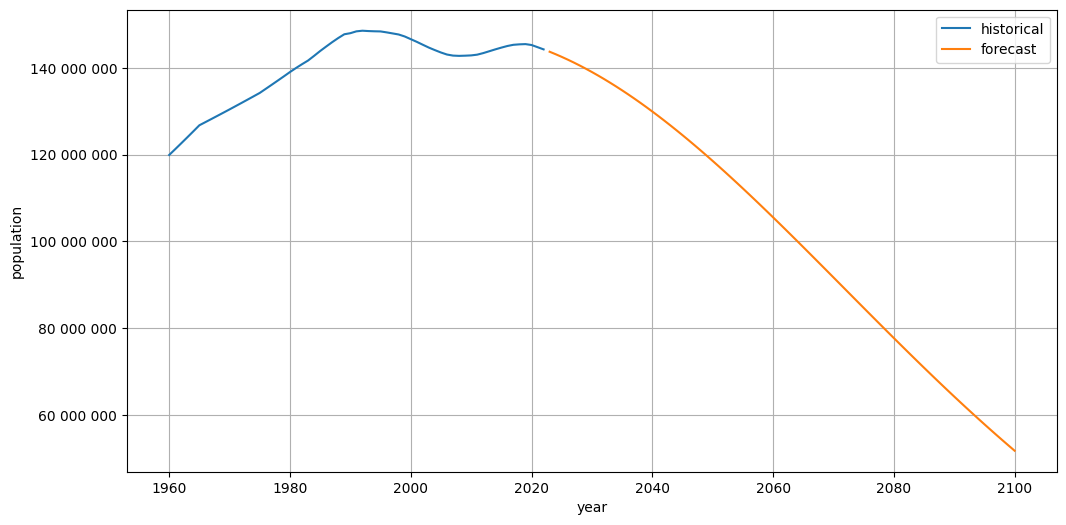

In [130]:
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.special import inv_boxcox
import matplotlib.ticker as ticker

df_rus = df[df['country_code'] == 'RUS'].sort_values('year')

y_train = df_rus['population_boxcox'].values
years_train = df_rus['year'].values
last_year = int(years_train[-1])
forecast_horizon = 2100 - last_year

model_rus = auto_arima(
    y_train,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

pred_boxcox = model_rus.predict(n_periods=forecast_horizon)
pred = inv_boxcox(pred_boxcox, lambda_bc)
pred = pred.astype(int)

years_forecast = np.arange(last_year + 1, 2101)

forecast_df = pd.DataFrame({
    'year': years_forecast,
    'population_forecast': pred
})

forecast_df

plt.figure(figsize=(12, 6))
plt.plot(df_rus['year'], df_rus['population'], label='historical')
plt.plot(years_forecast, pred, label='forecast')

plt.xlabel('year')
plt.ylabel('population')

plt.legend()
plt.grid(True)

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x):,}".replace(",", " "))
)

plt.show()


In [125]:
import pandas as pd
import numpy as np
from scipy.special import inv_boxcox

errors_by_window = {}

for window_name, countries in models_results['auto_arima_by_country'].items():
    if 'RUS' not in countries:
        continue

    train_end_year = [w[1] for w in windows if w[0] == window_name][0]
    horizon = [w[2] for w in windows if w[0] == window_name][0]

    df_rus = df[df['country_code'] == 'RUS'].sort_values('year')
    
    test = df_rus[(df_rus['year'] > train_end_year) & 
                  (df_rus['year'] <= train_end_year + horizon)]

    y_test_bc = test['population_boxcox'].values
    y_test = test['population'].values

    order = countries['RUS']['order']

    from pmdarima import ARIMA
    model = ARIMA(order=order).fit(df_rus[df_rus['year'] <= train_end_year]['population_boxcox'])

    y_pred_bc = model.predict(n_periods=len(y_test_bc))
    y_pred = inv_boxcox(y_pred_bc, lambda_bc)

    signed_errors = y_pred - y_test

    errors_by_window[window_name] = pd.DataFrame({
        'year': test['year'].values,
        'true': y_test,
        'pred': y_pred,
        'error_signed': signed_errors
    })

pd.options.display.float_format = '{:,.0f}'.format

errors_pretty = {}

for w in errors_by_window:  # твой словарь A/B/C
    df_w = errors_by_window[w].copy()
    df_w['true'] = df_w['true'].astype(int)
    df_w['pred'] = df_w['pred'].astype(int)
    df_w['error_signed'] = df_w['error_signed'].astype(int)
    errors_pretty[w] = df_w

errors_pretty


/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/mnt/c/WSL/ML/ML_project/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is availabl

{'A':     year       true       pred  error_signed
 40  2000  146596869  146705531        108662
 41  2001  145976482  146143598        167116
 42  2002  145306497  145529579        223082
 43  2003  144648618  144864131        215513
 44  2004  144067316  144147966         80650
 45  2005  143518814  143381846       -136967
 46  2006  143049637  142566584       -483052
 47  2007  142805114  141703041      -1102072
 48  2008  142742366  140792129      -1950236
 49  2009  142785348  139834803      -2950544,
 'B':     year       true       pred  error_signed
 45  2005  143518814  143437834        -80979
 46  2006  143049637  142760810       -288826
 47  2007  142805114  142036923       -768190
 48  2008  142742366  141266900      -1475465
 49  2009  142785348  140451512      -2333835
 50  2010  142849468  139591570      -3257897
 51  2011  143018195  138687929      -4330265
 52  2012  143378447  137741483      -5636963
 53  2013  143805638  136753163      -7052474
 54  2014  144237223  1